In [61]:
import torch
import numpy as np
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [62]:
import pandas as pd

# Load ETH CSV
eth_df = pd.read_csv(r'feature_datasets\ETH_features.csv', parse_dates=True, index_col=0)

# Define X and y
eth_y = eth_df['Close'].shift(-1)          # next-day close price
eth_X = eth_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
eth_X = eth_X.iloc[:-1]
eth_y = eth_y.iloc[:-1]

# Optional: check shapes
print("ETH X shape:", eth_X.shape)
print("ETH y shape:", eth_y.shape)

ETH X shape: (915, 29)
ETH y shape: (915,)


## Basic 70-30 split

In [63]:
# 70% train / 30% test split (time-based)
split_idx = int(len(eth_X) * 0.7)

eth_X_train = eth_X.iloc[:split_idx].values
eth_X_test  = eth_X.iloc[split_idx:].values

eth_y_train = eth_y.iloc[:split_idx].values
eth_y_test  = eth_y.iloc[split_idx:].values

print("ETH X_train shape:", eth_X_train.shape)
print("ETH X_test shape:", eth_X_test.shape)
print("ETH y_train shape:", eth_y_train.shape)
print("ETH y_test shape:", eth_y_test.shape)

ETH X_train shape: (640, 29)
ETH X_test shape: (275, 29)
ETH y_train shape: (640,)
ETH y_test shape: (275,)


In [64]:
eth_test_dates = eth_df.index[-len(eth_X_test):]  

In [65]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
eth_X_train_scaled = scaler.fit_transform(eth_X_train)

# Transform TEST using the same scaler
eth_X_test_scaled = scaler.transform(eth_X_test)

# Check shapes
print("Scaled X_train shape:", eth_X_train_scaled.shape)
print("Scaled X_test shape:", eth_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [66]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
eth_y_train_scaled = y_scaler.fit_transform(eth_y_train.reshape(-1,1)).flatten()

# Scale test target
eth_y_test_scaled = y_scaler.transform(eth_y_test.reshape(-1,1)).flatten()

In [67]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for ETH using scaled target
eth_X_train_seq, eth_y_train_seq = create_sequences(eth_X_train_scaled, eth_y_train_scaled, time_steps=30)
eth_X_test_seq, eth_y_test_seq = create_sequences(eth_X_test_scaled, eth_y_test_scaled, time_steps=30)

# Check shapes
print("ETH X_train_seq shape:", eth_X_train_seq.shape)
print("ETH y_train_seq shape:", eth_y_train_seq.shape)
print("ETH X_test_seq shape:", eth_X_test_seq.shape)
print("ETH y_test_seq shape:", eth_y_test_seq.shape)

ETH X_train_seq shape: (610, 30, 29)
ETH y_train_seq shape: (610,)
ETH X_test_seq shape: (245, 30, 29)
ETH y_test_seq shape: (245,)


### Train Bi_LSTM

In [68]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [69]:
# Get number of features from the sequences
input_size = eth_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)

In [70]:
model = train_model(model, eth_X_train_seq, eth_y_train_seq, epochs=50,batch_size=32, lr=0.001
)

Epoch [10/50], Loss: 0.005471
Epoch [20/50], Loss: 0.004420
Epoch [30/50], Loss: 0.005601
Epoch [40/50], Loss: 0.009393
Epoch [50/50], Loss: 0.001327


In [71]:
eth_preds = predict_model(model, eth_X_test_seq)

# check
print("Predictions shape:", eth_preds.shape)
print("First 10 predictions:", eth_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.26330063]
 [0.2469298 ]
 [0.24904796]
 [0.24666044]
 [0.24113774]
 [0.23902644]
 [0.22917995]
 [0.21925   ]
 [0.21120596]
 [0.20816484]]


In [72]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
eth_preds_actual = y_scaler.inverse_transform(eth_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
eth_y_test_actual = eth_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(eth_y_test_actual, eth_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(eth_y_test_actual, eth_preds_actual)
r2 = r2_score(eth_y_test_actual, eth_preds_actual)
mape = np.mean(np.abs((eth_y_test_actual - eth_preds_actual) / eth_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 14552.26
RMSE: 120.63
MAE: 100.56
R2 Score: 0.6537
MAPE: 5.59%


In [73]:
eth_preds_actual = y_scaler.inverse_transform(eth_preds.reshape(-1,1))

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = eth_df.index[-len(eth_X_test):][30:]  # test dates aligned with sequences
actual_seq = eth_y_test[30:]                      # actual prices aligned
pred_seq = eth_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,1870.789307,1999.037231
2023-05-03,1904.651855,1936.526123
2023-05-04,1877.704102,1944.614258
2023-05-05,1995.060913,1935.497559
2023-05-06,1900.221802,1914.409302
...,...,...
2023-12-28,2347.566162,2346.491455
2023-12-29,2300.690674,2408.696045
2023-12-30,2292.065430,2429.754883


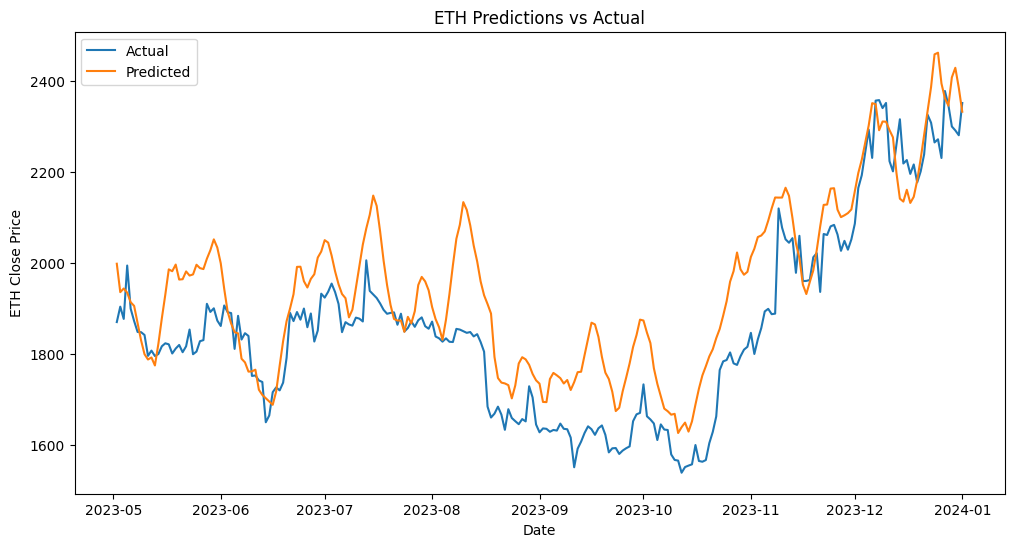

In [75]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("ETH Close Price")
plt.title("ETH Predictions vs Actual")
plt.legend()
plt.show()

## Each year 70% train split

In [76]:
# Get unique years from your DataFrame index
years = eth_df.index.year.unique()
print("Years in dataset:", years)

Years in dataset: Index([2021, 2022, 2023, 2024], dtype='int32', name='Date')


In [77]:
X_train_list = []
y_train_list = []

In [78]:
for year in years:
    # Filter data for this year
    eth_year = eth_df[eth_df.index.year == year]

    # Calculate split index for 70%
    split_idx = int(len(eth_year) * 0.7)

    # Take first 70% as training
    X_train_year = eth_year.iloc[:split_idx, 1:].values  # all features except target column
    y_train_year = eth_year.iloc[:split_idx, 0].values   # target column (e.g., next-day Close)

    # Append to lists
    X_train_list.append(X_train_year)
    y_train_list.append(y_train_year)

    print(f"Year {year}: {len(X_train_year)} train samples")

Year 2021: 129 train samples
Year 2022: 255 train samples
Year 2023: 255 train samples
Year 2024: 0 train samples


In [79]:
import numpy as np

# Stack all years’ train sets
X_train_combined = np.vstack(X_train_list)
y_train_combined = np.hstack(y_train_list)

print("Combined X_train shape:", X_train_combined.shape)
print("Combined y_train shape:", y_train_combined.shape)

Combined X_train shape: (639, 29)
Combined y_train shape: (639,)


In [80]:
X_test_list = []
y_test_list = []

In [81]:
for year in years:
    eth_year = eth_df[eth_df.index.year == year]

    # Calculate split index (same as for train)
    split_idx = max(1, int(len(eth_year) * 0.7))  # ensures at least 1 sample in train

    # Take the remaining 30% as test
    X_test_year = eth_year.iloc[split_idx:, 1:].values   # features
    y_test_year = eth_year.iloc[split_idx:, 0].values    # target

    # Append to test lists
    X_test_list.append(X_test_year)
    y_test_list.append(y_test_year)

    print(f"Year {year}: {len(X_test_year)} test samples")


Year 2021: 56 test samples
Year 2022: 110 test samples
Year 2023: 110 test samples
Year 2024: 0 test samples


In [82]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [83]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_combined)
y_train_scaled = y_scaler.fit_transform(y_train_combined.reshape(-1,1)).flatten()

In [84]:
X_test_scaled = x_scaler.transform(X_test_combined)
y_test_scaled = y_scaler.transform(y_test_combined.reshape(-1,1)).flatten()

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
print("Scaled y_train shape:", y_train_scaled.shape)
print("Scaled y_test shape:", y_test_scaled.shape)

Scaled X_train shape: (639, 29)
Scaled X_test shape: (276, 29)
Scaled y_train shape: (639,)
Scaled y_test shape: (276,)


In [85]:
import numpy as np

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for train and test
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

# Check shapes
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (609, 30, 29)
y_train_seq shape: (609,)
X_test_seq shape: (246, 30, 29)
y_test_seq shape: (246,)


### training

In [86]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [87]:
# Get number of features from the sequences
input_size = X_train_seq.shape[2]   # use the combined train sequences

# Initialize Bi-LSTM model
model_y = BiLSTM(input_size=input_size)

In [88]:
model_y = train_model(model_y, X_train_seq, y_train_seq, epochs=50, batch_size=32, lr=0.001)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning:

Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.



Epoch [10/50], Loss: 0.009113
Epoch [20/50], Loss: 0.004074
Epoch [30/50], Loss: 0.003018
Epoch [40/50], Loss: 0.003914
Epoch [50/50], Loss: 0.008616


In [89]:
eth_preds_ev_year =predict_model(model_y, X_test_seq)
eth_preds_ev_year[:10]

array([[0.8723195 ],
       [0.87296116],
       [0.89045435],
       [0.8967585 ],
       [0.88430023],
       [0.8509635 ],
       [0.83768255],
       [0.8409052 ],
       [0.8109757 ],
       [0.80012643]], dtype=float32)

In [90]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the trained model
eth_preds_ev_year = predict_model(model_y, X_test_seq)

# Inverse scale predictions to original price values
eth_preds_actual = y_scaler.inverse_transform(eth_preds_ev_year.reshape(-1,1))

# Inverse scale the test targets
eth_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

# Calculate metrics
mse = mean_squared_error(eth_y_test_actual, eth_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(eth_y_test_actual, eth_preds_actual)
r2 = r2_score(eth_y_test_actual, eth_preds_actual)
mape = np.mean(np.abs((eth_y_test_actual - eth_preds_actual) / eth_y_test_actual)) * 100

# Print results
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 35183.05
RMSE: 187.57
MAE: 109.69
R2 Score: 0.9466
MAPE: 6.53%


In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# Actual and predicted prices
actual_test_seq = y_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
predicted_test_seq = eth_preds_actual.flatten()

# Create DataFrame for plotting (no Date index)
df_eth_plot_year = pd.DataFrame({
    "Actual": actual_test_seq,
    "Predicted": predicted_test_seq
})

# Display first few rows
df_eth_plot_year.head()

,Actual,Predicted
0,4358.737305,4145.812988
1,4315.061523,4148.131836
2,4439.357910,4211.344238
3,4119.815918,4234.124512
4,3908.496094,4189.105957


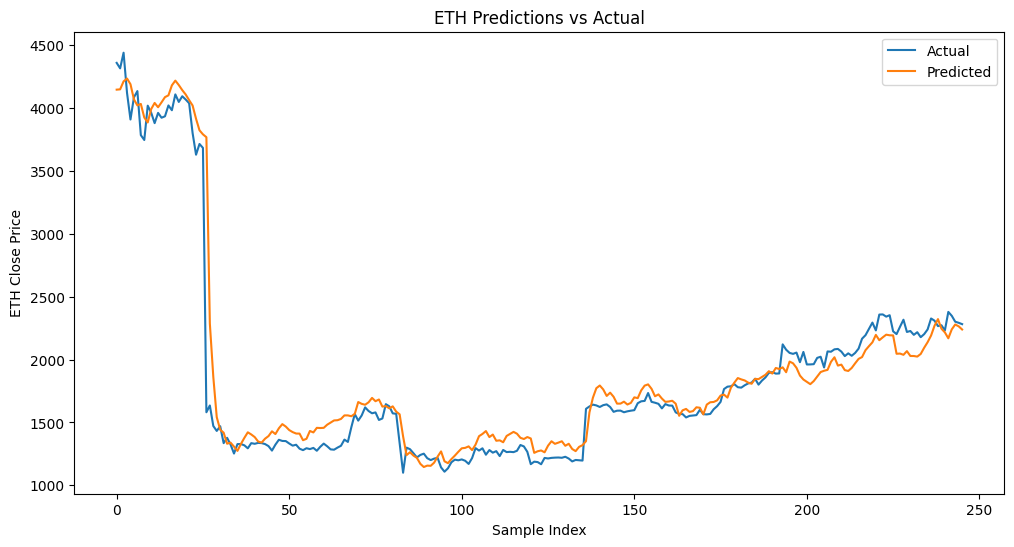

In [92]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(df_eth_plot_year["Actual"], label="Actual")
plt.plot(df_eth_plot_year["Predicted"], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("ETH Close Price")
plt.title("ETH Predictions vs Actual")
plt.legend()
plt.show()

## Three-quaters train

In [93]:
# 75% train / 25% test split (time-based)
q3_split_idx = int(len(eth_X) * 0.75)

eth_q3_X_train = eth_X.iloc[:q3_split_idx].values
eth_q3_X_test  = eth_X.iloc[q3_split_idx:].values

eth_q3_y_train = eth_y.iloc[:q3_split_idx].values
eth_q3_y_test  = eth_y.iloc[q3_split_idx:].values

# Shape checks
print("Q3 ETH X_train shape:", eth_q3_X_train.shape)
print("Q3 ETH X_test shape:", eth_q3_X_test.shape)
print("Q3 ETH y_train shape:", eth_q3_y_train.shape)
print("Q3 ETH y_test shape:", eth_q3_y_test.shape)

Q3 ETH X_train shape: (686, 29)
Q3 ETH X_test shape: (229, 29)
Q3 ETH y_train shape: (686,)
Q3 ETH y_test shape: (229,)


In [94]:
# Assuming btc_df has Date as index
eth_q3_test_dates = eth_df.index[-len(eth_q3_X_test):]

print("Q3 test dates length:", len(eth_q3_test_dates))

Q3 test dates length: 229


In [95]:
from sklearn.preprocessing import MinMaxScaler

# Feature scaler
eth_q3_X_scaler = MinMaxScaler()

# Fit on TRAIN only
eth_q3_X_train_scaled = eth_q3_X_scaler.fit_transform(eth_q3_X_train)

# Transform TEST using same scaler
eth_q3_X_test_scaled = eth_q3_X_scaler.transform(eth_q3_X_test)

print("Q3 Scaled X_train shape:", eth_q3_X_train_scaled.shape)
print("Q3 Scaled X_test shape:", eth_q3_X_test_scaled.shape)


Q3 Scaled X_train shape: (686, 29)
Q3 Scaled X_test shape: (229, 29)


In [96]:
# Target scaler
eth_q3_y_scaler = MinMaxScaler()

# Scale training target
eth_q3_y_train_scaled = eth_q3_y_scaler.fit_transform(
    eth_q3_y_train.reshape(-1, 1)
).flatten()

# Scale test target
eth_q3_y_test_scaled = eth_q3_y_scaler.transform(
    eth_q3_y_test.reshape(-1, 1)
).flatten()
14
print("Q3 Scaled y_train shape:", eth_q3_y_train_scaled.shape)
print("Q3 Scaled y_test shape:", eth_q3_y_test_scaled.shape)

Q3 Scaled y_train shape: (686,)
Q3 Scaled y_test shape: (229,)


In [97]:
import numpy as np

def create_sequences_q3(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

In [98]:
# Create sequences (30-day window)
eth_q3_X_train_seq, eth_q3_y_train_seq = create_sequences_q3(
    eth_q3_X_train_scaled,
    eth_q3_y_train_scaled,
    time_steps=30
)

eth_q3_X_test_seq, eth_q3_y_test_seq = create_sequences_q3(
    eth_q3_X_test_scaled,
    eth_q3_y_test_scaled,
    time_steps=30
)

# Final shape checks
print("Q3 X_train_seq shape:", eth_q3_X_train_seq.shape)
print("Q3 y_train_seq shape:", eth_q3_y_train_seq.shape)
print("Q3 X_test_seq shape:", eth_q3_X_test_seq.shape)
print("Q3 y_test_seq shape:", eth_q3_y_test_seq.shape)

Q3 X_train_seq shape: (656, 30, 29)
Q3 y_train_seq shape: (656,)
Q3 X_test_seq shape: (199, 30, 29)
Q3 y_test_seq shape: (199,)


### Model training

In [99]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [100]:
# Get number of features
eth_q3_input_size = eth_q3_X_train_seq.shape[2]

# Initialize model
eth_q3_model = BiLSTM(input_size=eth_q3_input_size)

In [101]:
# Train model
eth_q3_model = train_model(eth_q3_model, eth_q3_X_train_seq, eth_q3_y_train_seq, epochs=50, batch_size=32, lr=0.001)

Epoch [10/50], Loss: 0.006850
Epoch [20/50], Loss: 0.002155
Epoch [30/50], Loss: 0.003029
Epoch [40/50], Loss: 0.001149
Epoch [50/50], Loss: 0.005725


In [102]:
# Generate predictions
eth_q3_preds = predict_model(eth_q3_model, eth_q3_X_test_seq)

print("Q3 Predictions shape:", eth_q3_preds.shape)
print("First 10 Q3 predictions:", eth_q3_preds[:10])

Q3 Predictions shape: (199, 1)
First 10 Q3 predictions: [[0.18109027]
 [0.19861561]
 [0.21446724]
 [0.22758019]
 [0.23236088]
 [0.2402812 ]
 [0.2539231 ]
 [0.2593331 ]
 [0.24965526]
 [0.24545947]]


In [103]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the Q3 trained model
eth_q3_preds_eval = predict_model(eth_q3_model, eth_q3_X_test_seq)

# Inverse scale predictions to original price values
eth_q3_preds_actual = eth_q3_y_scaler.inverse_transform(
    eth_q3_preds_eval.reshape(-1, 1)
)

# Inverse scale the test targets
eth_q3_y_test_actual = eth_q3_y_scaler.inverse_transform(
    eth_q3_y_test_seq.reshape(-1, 1)
)

# Calculate metrics
eth_q3_mse = mean_squared_error(eth_q3_y_test_actual, eth_q3_preds_actual)
eth_q3_rmse = np.sqrt(eth_q3_mse)
eth_q3_mae = mean_absolute_error(eth_q3_y_test_actual, eth_q3_preds_actual)
eth_q3_r2 = r2_score(eth_q3_y_test_actual, eth_q3_preds_actual)
eth_q3_mape = np.mean(np.abs((eth_q3_y_test_actual - eth_q3_preds_actual) / eth_q3_y_test_actual)) * 100

# Print results
print(f"Q3 MSE: {eth_q3_mse:.2f}")
print(f"Q3 RMSE: {eth_q3_rmse:.2f}")
print(f"Q3 MAE: {eth_q3_mae:.2f}")
print(f"Q3 R2 Score: {eth_q3_r2:.4f}")
print(f"Q3 MAPE: {eth_q3_mape:.2f}%")

Q3 MSE: 12278.01
Q3 RMSE: 110.81
Q3 MAE: 89.46
Q3 R2 Score: 0.7572
Q3 MAPE: 4.82%


In [104]:
# Inverse scale predictions
eth_q3_preds_actual = eth_q3_y_scaler.inverse_transform(
    eth_q3_preds.reshape(-1, 1)
)

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

# Align dates and values
eth_q3_dates_seq = eth_df.index[-len(eth_q3_X_test):][30:]
eth_q3_actual_seq = eth_q3_y_test[30:]
eth_q3_pred_seq = eth_q3_preds_actual.flatten()

# Create DataFrame
eth_q3_df_plot = pd.DataFrame({
    "Date": eth_q3_dates_seq,
    "Actual": eth_q3_actual_seq,
    "Predicted": eth_q3_pred_seq
})

eth_q3_df_plot.set_index("Date", inplace=True)
eth_q3_df_plot.head(10)


,Actual,Predicted
Date,,
2023-06-17,1727.204102,1685.120972
2023-06-18,1720.577515,1752.040649
2023-06-19,1737.659424,1812.569336
2023-06-20,1792.119995,1862.640503
2023-06-21,1891.007202,1880.895386
2023-06-22,1872.942993,1911.138672
2023-06-23,1892.862061,1963.229614
2023-06-24,1876.059692,1983.887451
2023-06-25,1900.506104,1946.932983


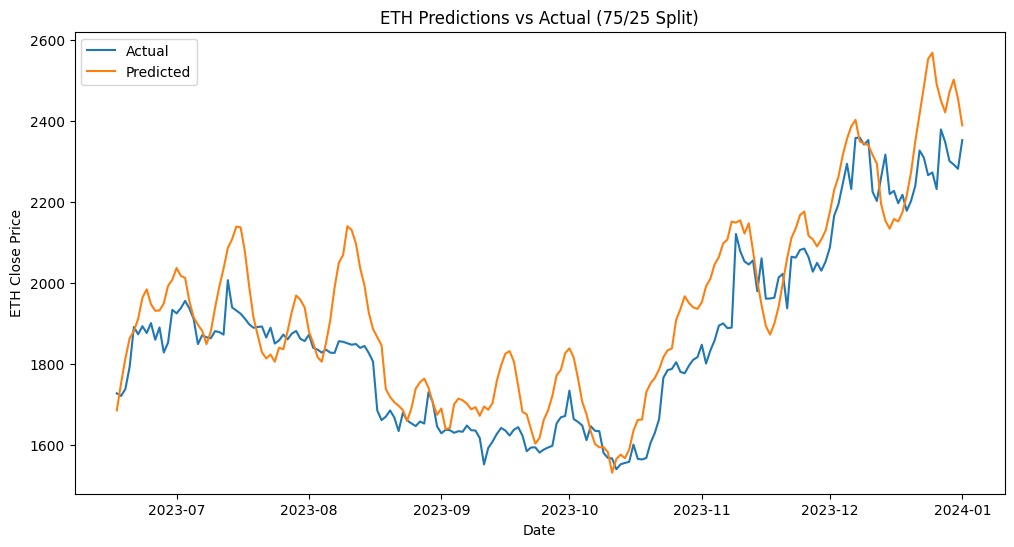

In [106]:
plt.figure(figsize=(12, 6))
plt.plot(eth_q3_df_plot["Actual"], label="Actual")
plt.plot(eth_q3_df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("ETH Close Price")
plt.title("ETH Predictions vs Actual (75/25 Split)")
plt.legend()
plt.show()

## Saving the best model (out of accuracy) for Ethereum

In [107]:
# import joblib
# joblib.dump(model_y, "Ethereum_base_model.pkl")

# Finetuning

In [108]:
import optuna

In [109]:
from sklearn.model_selection import train_test_split

eth_X_train_tune, eth_X_val_tune, eth_y_train_tune, eth_y_val_tune = train_test_split(
    eth_X_train_seq,
    eth_y_train_seq,
    test_size=0.2,
    shuffle=False
)

In [110]:
import torch
import numpy as np

def objective(trial):
    hidden_size = trial.suggest_int("hidden_size", 32, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    input_size = eth_X_train_tune.shape[2]

    model = BiLSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    )

    model = train_model(
        model,
        eth_X_train_tune,
        eth_y_train_tune,
        epochs=30,
        batch_size=batch_size,
        lr=lr
    )

    preds = predict_model(model, eth_X_val_tune)
    val_loss = np.mean((preds.flatten() - eth_y_val_tune) ** 2)

    return val_loss

In [111]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2026-03-17 14:02:11,851] A new study created in memory with name: no-name-f9f9bcf2-d475-4103-99d5-8c654c472c63


Epoch [10/30], Loss: 0.008571
Epoch [20/30], Loss: 0.002352


[I 2026-03-17 14:02:55,937] Trial 0 finished with value: 0.0012921302261555843 and parameters: {'hidden_size': 126, 'num_layers': 3, 'lr': 0.00023773941163561226, 'batch_size': 64}. Best is trial 0 with value: 0.0012921302261555843.


Epoch [30/30], Loss: 0.006819
Epoch [10/30], Loss: 0.003397
Epoch [20/30], Loss: 0.005063


[I 2026-03-17 14:03:05,655] Trial 1 finished with value: 0.00154362937881316 and parameters: {'hidden_size': 40, 'num_layers': 1, 'lr': 0.00480642561566015, 'batch_size': 16}. Best is trial 0 with value: 0.0012921302261555843.


...

Epoch [30/30], Loss: 0.004075
Epoch [10/30], Loss: 0.013446
Epoch [20/30], Loss: 0.001937


[I 2026-03-17 14:06:14,141] Trial 8 finished with value: 0.0028752510363049635 and parameters: {'hidden_size': 35, 'num_layers': 3, 'lr': 0.001861606672531708, 'batch_size': 64}. Best is trial 5 with value: 0.0008740428828175319.


Epoch [30/30], Loss: 0.002863
Epoch [10/30], Loss: 0.004234
Epoch [20/30], Loss: 0.005326


[I 2026-03-17 14:06:25,774] Trial 9 finished with value: 0.002628575902925429 and parameters: {'hidden_size': 109, 'num_layers': 1, 'lr': 0.00024523147013909605, 'batch_size': 32}. Best is trial 5 with value: 0.0008740428828175319.


Epoch [30/30], Loss: 0.002696


In [112]:
print(study.best_params)
print(study.best_value)

{'hidden_size': 119, 'num_layers': 2, 'lr': 0.0006996494182969881, 'batch_size': 16}
0.0008740428828175319


In [113]:
import optuna.visualization as vis

vis.plot_optimization_history(study)

In [114]:
vis.plot_param_importances(study)

In [115]:
vis.plot_parallel_coordinate(study)

In [116]:
# Get best parameters
best_params = study.best_params

# Get input size
input_size = eth_X_train_seq.shape[2]

# Create tuned model
eth_model_tuned = BiLSTM(
    input_size=input_size,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"]
)

# Train using full training sequences
eth_model_tuned = train_model(
    eth_model_tuned,
    eth_X_train_seq,
    eth_y_train_seq,
    epochs=50,
    batch_size=best_params["batch_size"],
    lr=best_params["lr"]
)

Epoch [10/50], Loss: 0.013540
Epoch [20/50], Loss: 0.006445
Epoch [30/50], Loss: 0.011138
Epoch [40/50], Loss: 0.005759
Epoch [50/50], Loss: 0.003436


In [117]:
eth_preds_tuned = predict_model(eth_model_tuned, eth_X_test_seq)
eth_preds_tuned[:10]

array([[0.2117929 ],
       [0.20513572],
       [0.19918668],
       [0.19734581],
       [0.19416776],
       [0.19270192],
       [0.18483575],
       [0.17581843],
       [0.16373381],
       [0.16236739]], dtype=float32)

In [118]:
eth_preds_tuned_actual = y_scaler.inverse_transform(eth_preds_tuned.reshape(-1,1))

In [119]:
eth_y_test_actual = y_scaler.inverse_transform(eth_y_test_seq.reshape(-1,1))

In [120]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(eth_y_test_actual, eth_preds_tuned_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(eth_y_test_actual, eth_preds_tuned_actual)
r2 = r2_score(eth_y_test_actual, eth_preds_tuned_actual)
mape = np.mean(np.abs((eth_y_test_actual - eth_preds_tuned_actual) / eth_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 25174.57
RMSE: 158.66
MAE: 134.42
R2 Score: 0.3311
MAPE: 7.19%


# Saving the best performed model

In [122]:
torch.save(eth_q3_model, "ETH_final_model.pth")